# Erlang C System and UI Tests

This notebook records manual browser tests for the complete Erlang C application. You perform each action in the browser, then enter the result and optional screenshot path here.

Before testing, activate `.venv`, start the application with `python -m uvicorn api:app --reload`, and open `http://127.0.0.1:8000`.

In [10]:
from pathlib import Path
from datetime import datetime
import pandas as pd
from IPython.display import Markdown, Image, display

cwd = Path.cwd()
PROJECT_DIR = cwd if (cwd / 'calculator.py').exists() else cwd.parent
TESTS_DIR = PROJECT_DIR / 'tests'
EVIDENCE_DIR = TESTS_DIR / 'evidence'
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)

SYSTEM_RESULTS = {}

TEST_CASES = {
    'SYS-01': {'description': 'Dashboard opens correctly', 'action': 'Open http://127.0.0.1:8000', 'expected': 'Dashboard loads without an error'},
    'SYS-02': {'description': 'Four valid CDR files are accepted', 'action': 'Select and upload cdr_2021.csv to cdr_2024.csv', 'expected': 'All four CSV files are accepted'},
    'SYS-03': {'description': 'Excel upload is rejected', 'action': 'Try to upload an .xlsx file', 'expected': 'A clear unsupported-file error is displayed'},
    'SYS-04': {'description': 'More than ten files are rejected', 'action': 'Try to upload 13 CSV files', 'expected': 'Upload is rejected with a clear message'},
    'SYS-05': {'description': 'Missing files are handled', 'action': 'Submit without selecting the required files', 'expected': 'A clear validation message is displayed'},
    'SYS-06': {'description': 'Zero forecast days are rejected', 'action': 'Enter 0 as forecast days and submit', 'expected': 'The value is rejected'},
    'SYS-07': {'description': 'Forecast days above 3650 are rejected', 'action': 'Enter 4000 as forecast days and submit', 'expected': 'The value is rejected'},
    'SYS-08': {'description': 'Valid forecast is generated', 'action': 'Upload valid files, use valid settings and generate forecast', 'expected': 'Forecast results are displayed without an error'},
    'SYS-09': {'description': 'Forecast charts display correctly', 'action': 'Inspect every forecast chart', 'expected': 'Charts have titles, axes and visible data'},
    'SYS-10': {'description': 'Monthly schedule is generated', 'action': 'Create the January 2025 schedule', 'expected': 'A schedule with agents, dates and shifts is displayed'},
    'SYS-11': {'description': 'Forecast or schedule download works', 'action': 'Download a result file and open it', 'expected': 'The downloaded file opens and contains data'},
    'SYS-12': {'description': 'Agent leave works', 'action': 'Apply leave to a working agent', 'expected': 'The agent is marked as leave and coverage is handled'},
    'SYS-13': {'description': 'Safe shift swap works', 'action': 'Swap two compatible agents on the same date', 'expected': 'Their shifts are exchanged successfully'},
    'SYS-14': {'description': 'Unsafe shift swap is rejected', 'action': 'Attempt a swap that breaks the rest rule', 'expected': 'The swap is rejected with an explanation'},
    'SYS-15': {'description': 'Application remains usable after refresh', 'action': 'Refresh the browser and use the dashboard again', 'expected': 'The page loads and remains usable'},
}

print('Setup complete')
print('Project directory:', PROJECT_DIR)
print('Screenshot directory:', EVIDENCE_DIR)
print('Number of system tests:', len(TEST_CASES))

Setup complete
Project directory: c:\Users\adept\Desktop\ADEPT\ERLANG\Calculator-Erlang-C
Screenshot directory: c:\Users\adept\Desktop\ADEPT\ERLANG\Calculator-Erlang-C\tests\evidence
Number of system tests: 15


## Test checklist

In [11]:
checklist = pd.DataFrame([
    {'test': test_id, **details}
    for test_id, details in TEST_CASES.items()
])
display(checklist)

,test,description,action,expected
0,SYS-01,Dashboard opens correctly,Open http://127.0.0.1:8000,Dashboard loads without an error
1,SYS-02,Four valid CDR files are accepted,Select and upload cdr_2021.csv to cdr_2024.csv,All four CSV files are accepted
2,SYS-03,Excel upload is rejected,Try to upload an .xlsx file,A clear unsupported-file error is displayed
3,SYS-04,More than ten files are rejected,Try to upload 13 CSV files,Upload is rejected with a clear message
4,SYS-05,Missing files are handled,Submit without selecting the required files,A clear validation message is displayed
5,SYS-06,Zero forecast days are rejected,Enter 0 as forecast days and submit,The value is rejected
6,SYS-07,Forecast days above 3650 are rejected,Enter 4000 as forecast days and submit,The value is rejected
7,SYS-08,Valid forecast is generated,"Upload valid files, use valid settings and gen...",Forecast results are displayed without an error
8,SYS-09,Forecast charts display correctly,Inspect every forecast chart,"Charts have titles, axes and visible data"
9,SYS-10,Monthly schedule is generated,Create the January 2025 schedule,"A schedule with agents, dates and shifts is di..."


## prompt-based entry

Run the helper cell once. Then perform each browser action and run its separate prompt cell.

In [3]:
def record_prompt(test_id):
    test = TEST_CASES[test_id]
    print('Test:', test_id, '—', test['description'])
    print('Action:', test['action'])
    print('Expected:', test['expected'])
    status = input('Status (PASS/FAIL/NOT RUN): ').strip().upper()
    if status not in {'PASS', 'FAIL', 'NOT RUN'}:
        raise ValueError('Status must be PASS, FAIL or NOT RUN')
    actual = input('What actually happened? ').strip()
    notes = input('Notes (optional): ').strip()
    screenshot = input('Screenshot path (optional): ').strip()
    screenshot_path = None
    if screenshot:
        entered = Path(screenshot)
        screenshot_path = entered if entered.is_absolute() else TESTS_DIR / entered
    SYSTEM_RESULTS[test_id] = {
        'test': test_id, 'description': test['description'],
        'expected': test['expected'], 'actual': actual, 'status': status,
        'notes': notes, 'screenshot': str(screenshot_path) if screenshot_path else '',
    }
    print(f'Saved {test_id}: {status}')
    if screenshot_path:
        if screenshot_path.exists():
            display(Image(filename=str(screenshot_path), width=700))
        else:
            print('Screenshot not found:', screenshot_path)

print('Prompt helper ready')

Prompt helper ready


### SYS-01 — Open the application
Expected: Dashboard loads without an error

Test: SYS-01 — Dashboard opens correctly
Action: Open http://127.0.0.1:8000
Expected: Dashboard loads without an error
Saved SYS-01: PASS


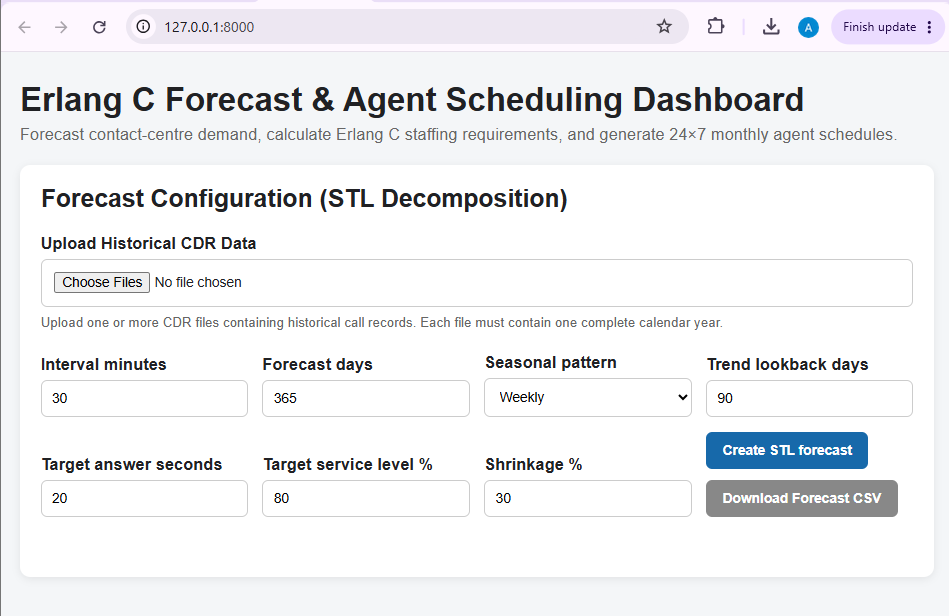

In [4]:
record_prompt('SYS-01')

### SYS-02 — Upload four valid CSV files
Expected: Files are accepted

Test: SYS-02 — Four valid CDR files are accepted
Action: Select and upload cdr_2021.csv to cdr_2024.csv
Expected: All four CSV files are accepted
Saved SYS-02: PASS


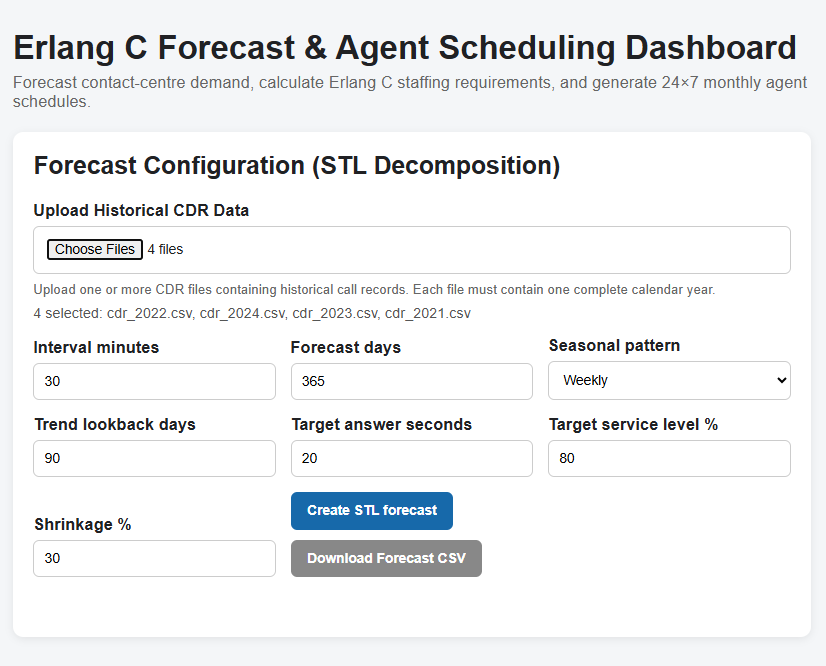

In [5]:
record_prompt('SYS-02')

### SYS-03 — Upload an Excel file
Expected: Clear validation error appears

Test: SYS-03 — Excel upload is rejected
Action: Try to upload an .xlsx file
Expected: A clear unsupported-file error is displayed
Saved SYS-03: PASS


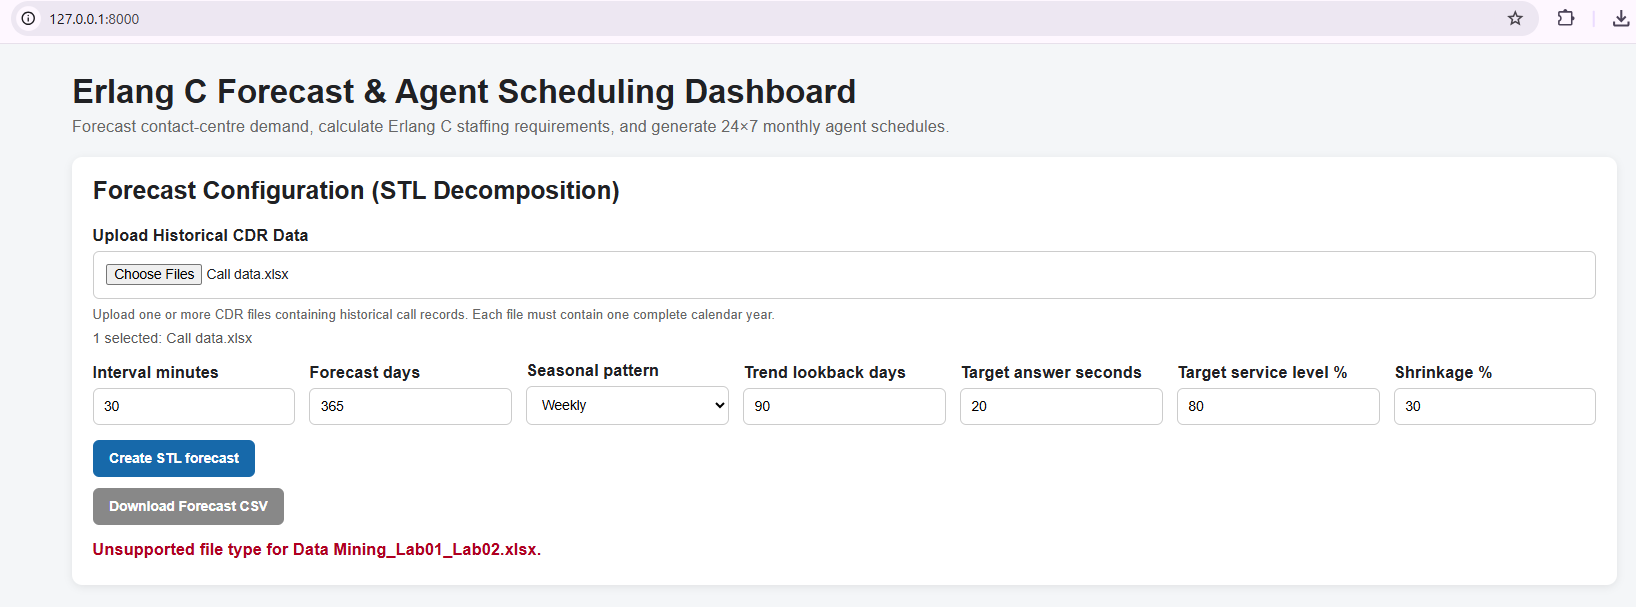

In [6]:
record_prompt('SYS-03')

### SYS-04 — Upload more than 10 files
Expected: Upload is rejected

Test: SYS-04 — More than ten files are rejected
Action: Try to upload 11 CSV files
Expected: Upload is rejected with a clear message
Saved SYS-04: PASS


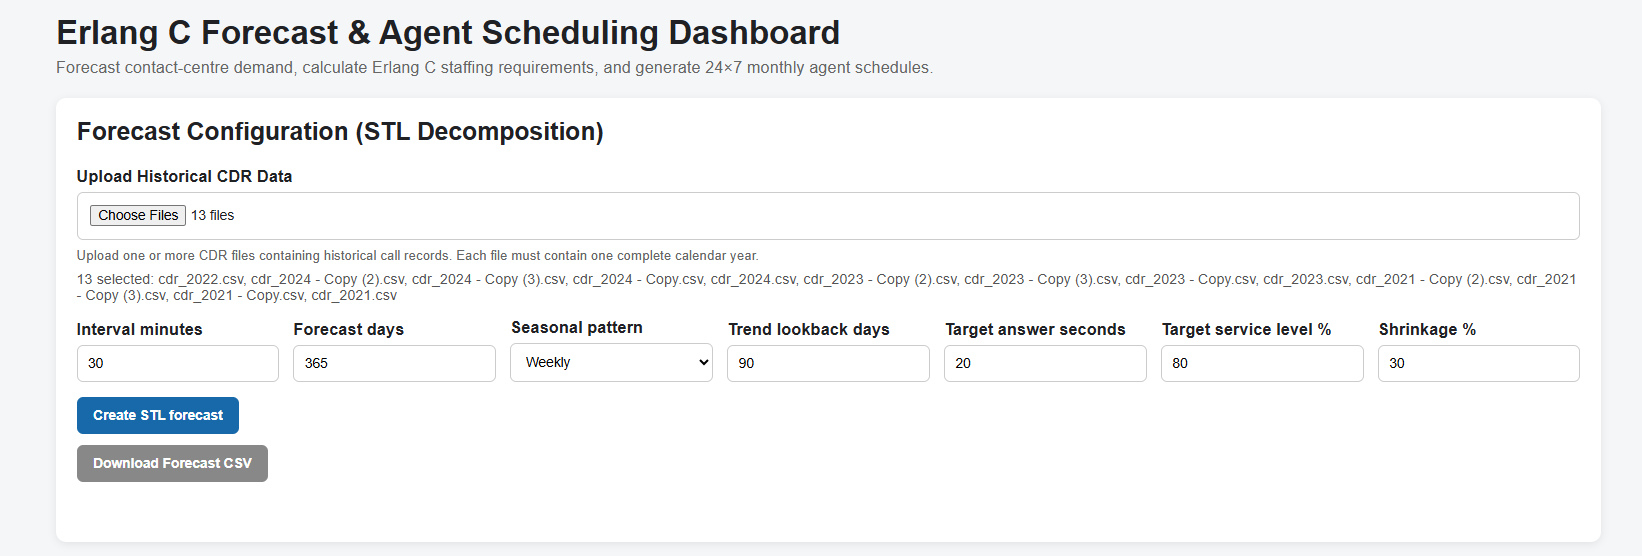

In [7]:
record_prompt('SYS-04')

### SYS-05 — Submit without required files
Expected: Clear error appears

Test: SYS-05 — Missing files are handled
Action: Submit without selecting the required files
Expected: A clear validation message is displayed
Saved SYS-05: PASS


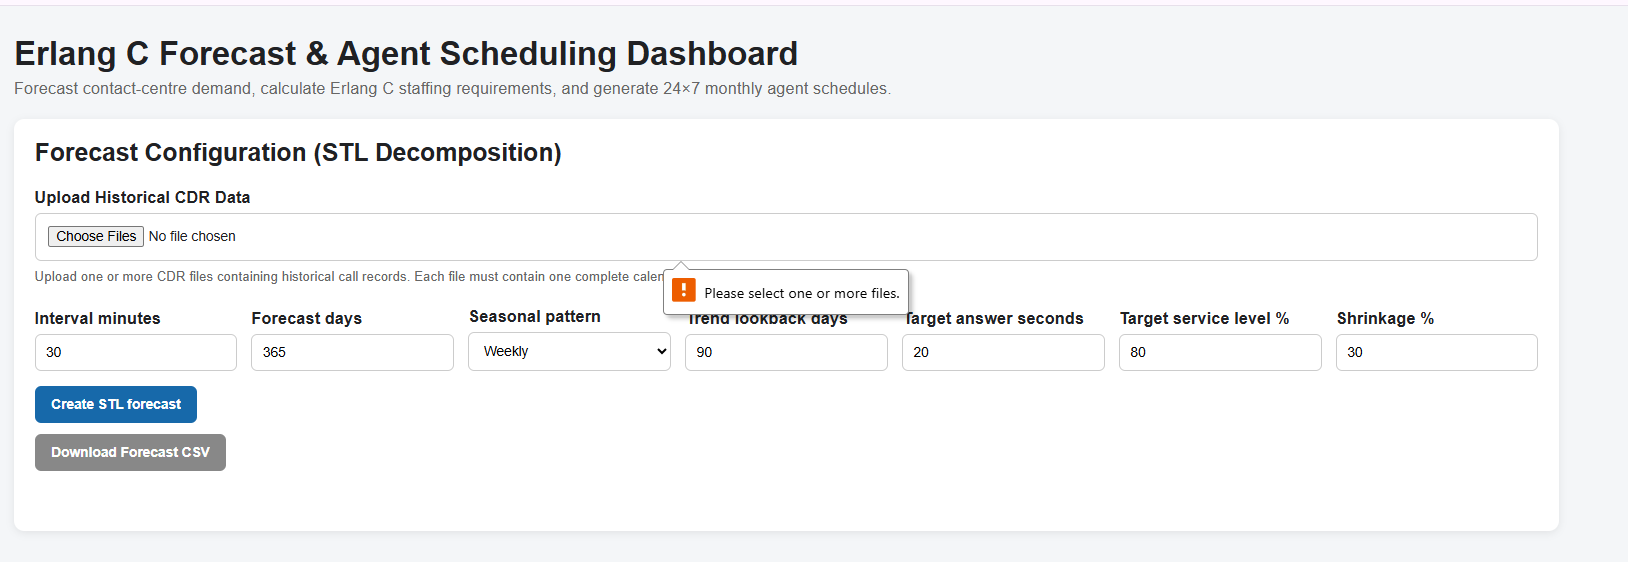

In [8]:
record_prompt('SYS-05')

### SYS-06 — Enter forecast days 0
Expected: Input is rejected

Test: SYS-06 — Zero forecast days are rejected
Action: Enter 0 as forecast days and submit
Expected: The value is rejected
Saved SYS-06: PASS


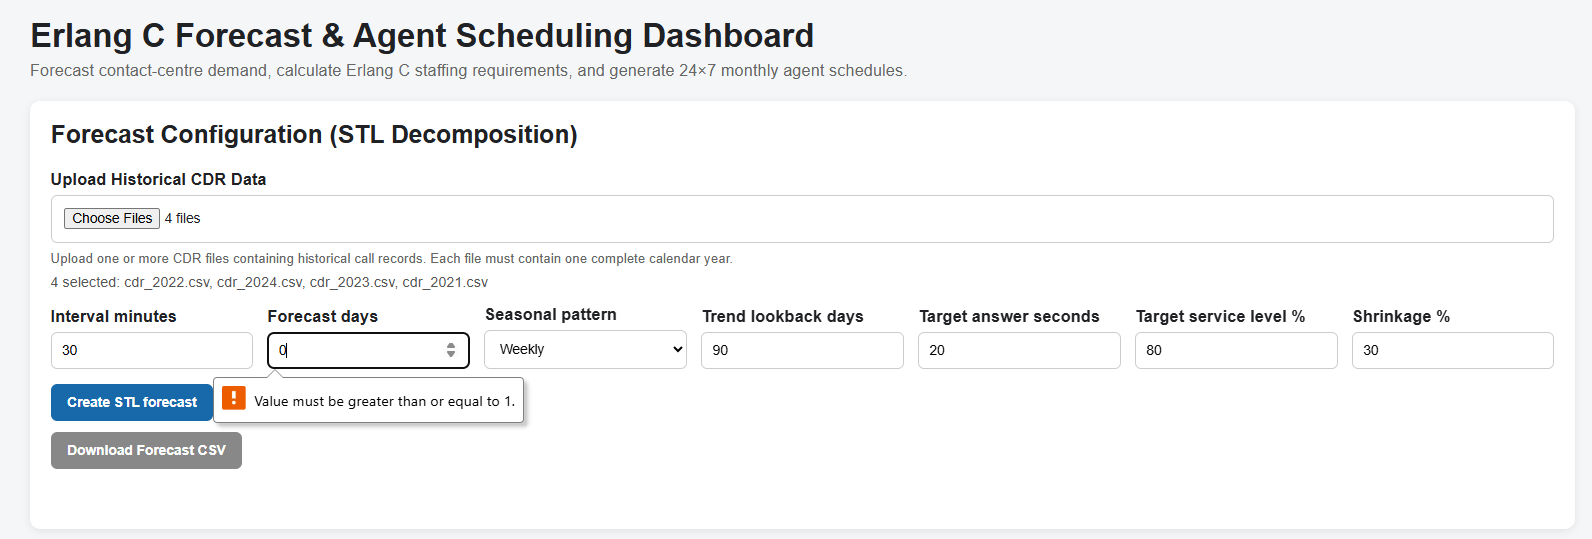

In [9]:
record_prompt('SYS-06')

### SYS-07 — Enter forecast days 4000
Expected: Input is rejected

Test: SYS-07 — Forecast days above 3650 are rejected
Action: Enter 4000 as forecast days and submit
Expected: The value is rejected
Saved SYS-07: PASS


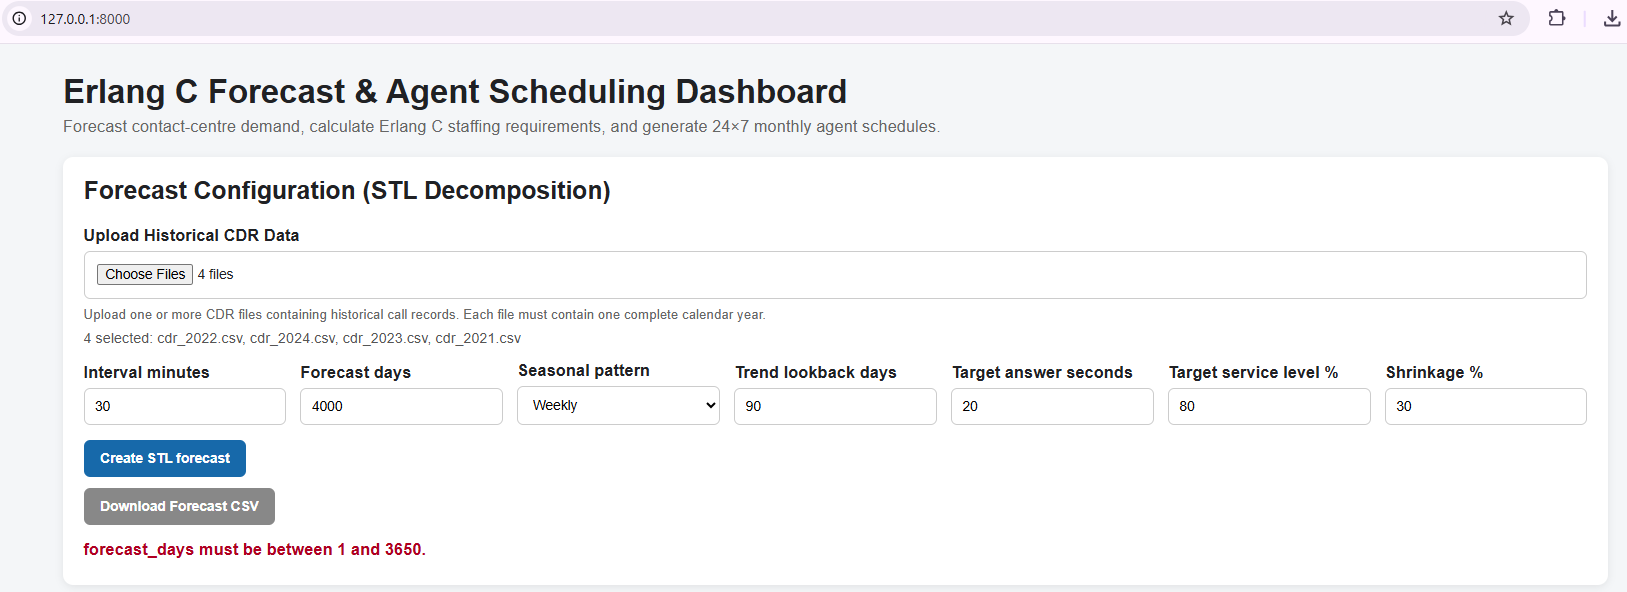

In [12]:
record_prompt('SYS-07')

### SYS-08 — Generate a valid forecast
Expected: Forecast results appear

Test: SYS-08 — Valid forecast is generated
Action: Upload valid files, use valid settings and generate forecast
Expected: Forecast results are displayed without an error
Saved SYS-08: PASS


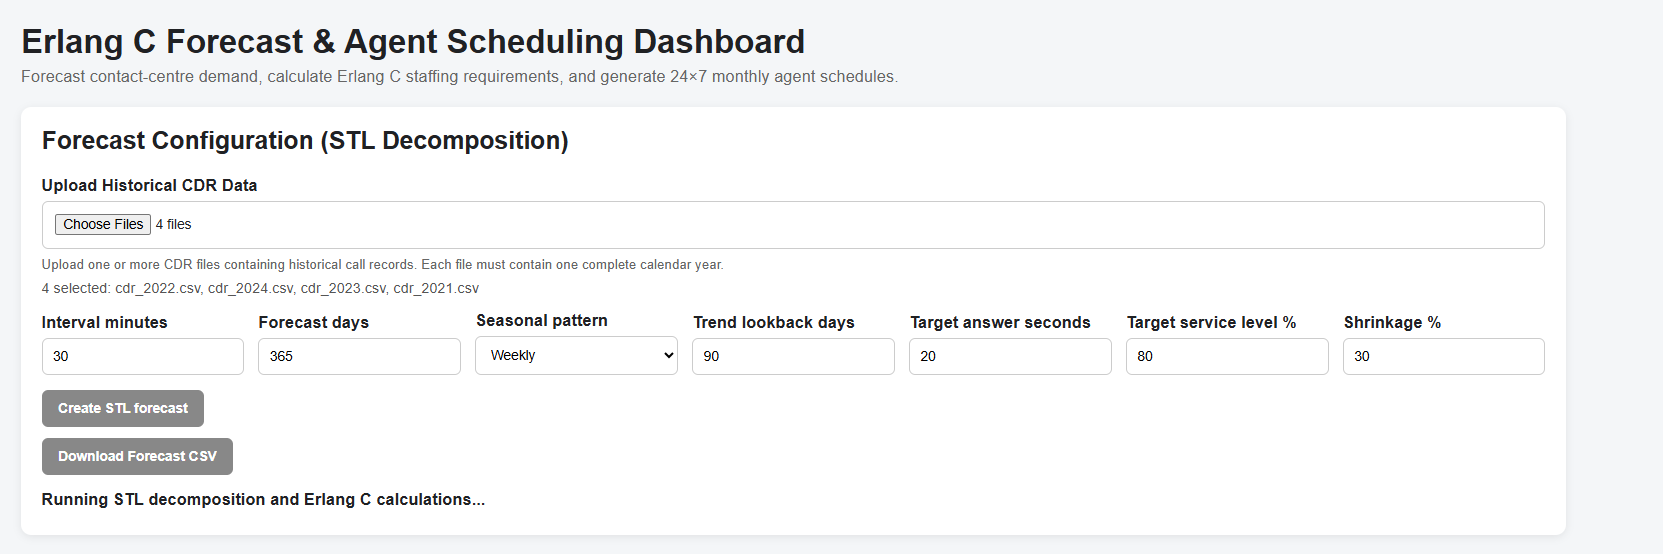

In [13]:
record_prompt('SYS-08')

### SYS-09 — Check forecast charts
Expected: Charts display correctly

Test: SYS-09 — Forecast charts display correctly
Action: Inspect every forecast chart
Expected: Charts have titles, axes and visible data
Saved SYS-09: PASS


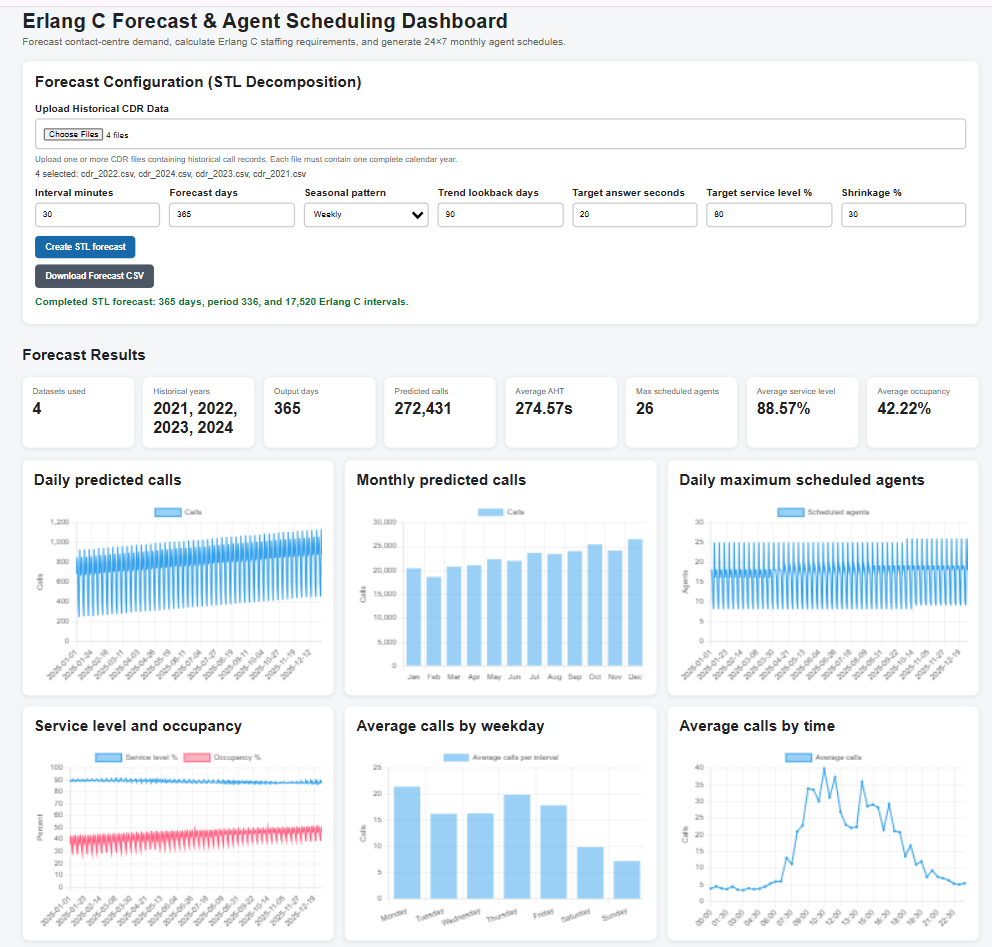

In [15]:
record_prompt('SYS-09')

### SYS-10 — Create the January schedule
Expected: Schedule is displayed

Test: SYS-10 — Monthly schedule is generated
Action: Create the January 2025 schedule
Expected: A schedule with agents, dates and shifts is displayed
Saved SYS-10: PASS


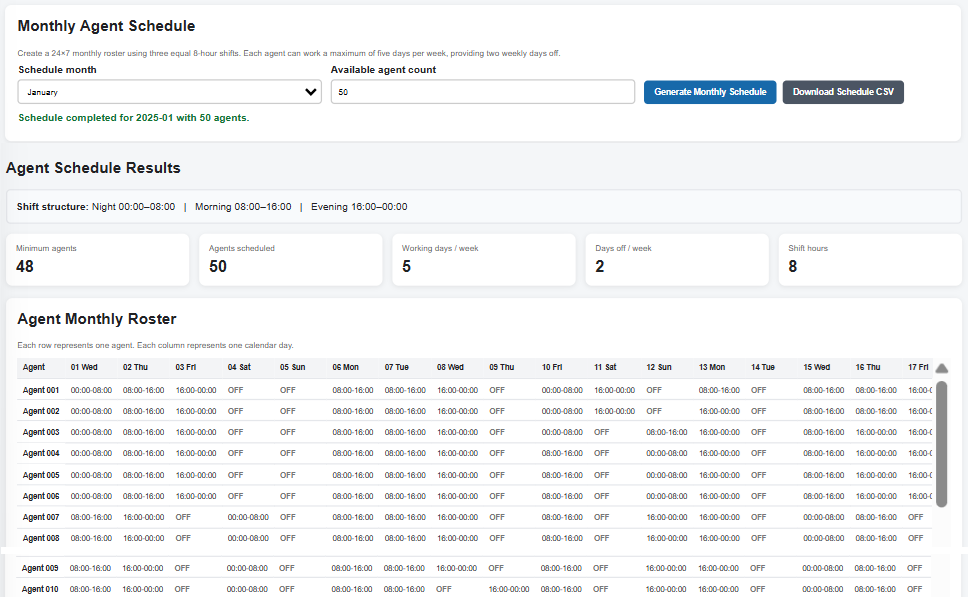

In [18]:
record_prompt('SYS-10')

### SYS-11 — Download forecast or schedule
Expected: Downloaded file opens correctly

Test: SYS-11 — Forecast or schedule download works
Action: Download a result file and open it
Expected: The downloaded file opens and contains data
Saved SYS-11: PASS


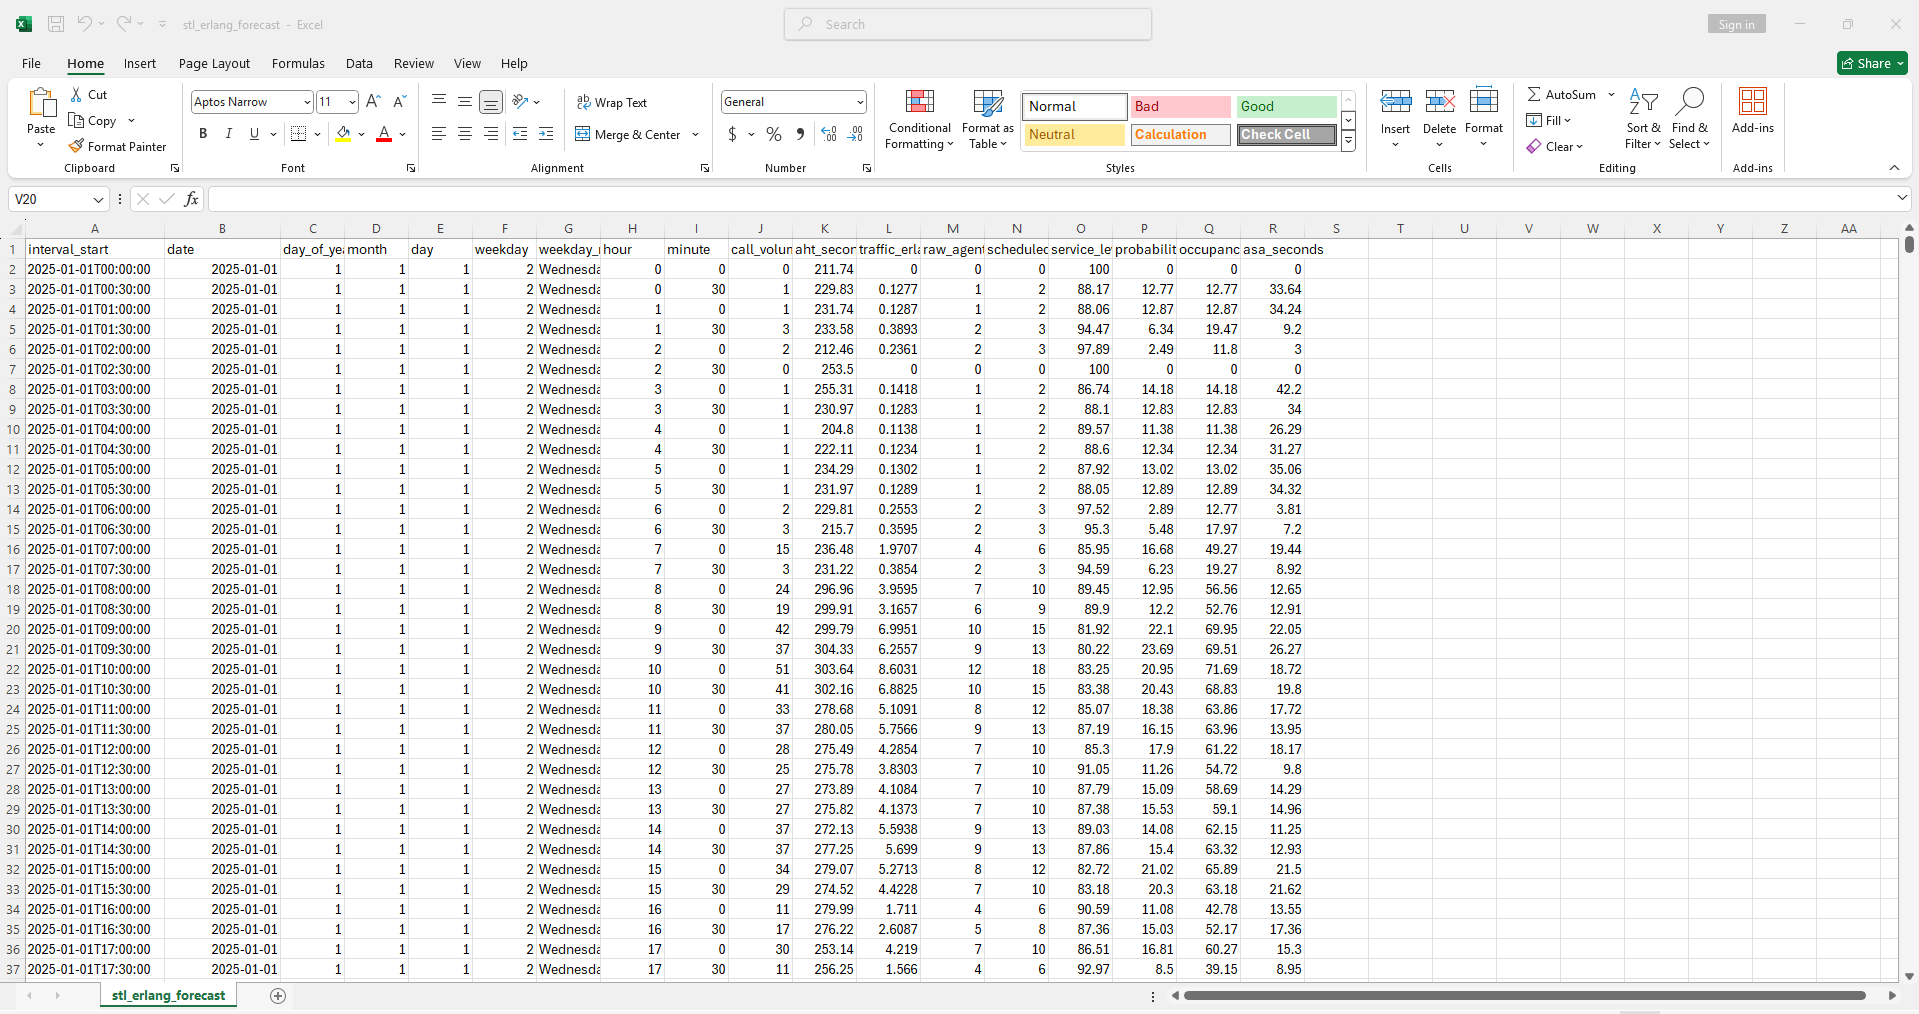

In [17]:
record_prompt('SYS-11')

### SYS-12 — Apply leave
Expected: Agent becomes unavailable or is replaced

Test: SYS-12 — Agent leave works
Action: Apply leave to a working agent
Expected: The agent is marked as leave and coverage is handled
Saved SYS-12: PASS


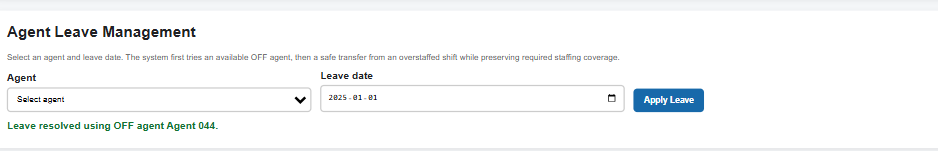

In [19]:
record_prompt('SYS-12')

### SYS-13 — Perform a valid shift swap
Expected: Shifts are exchanged

Test: SYS-13 — Safe shift swap works
Action: Swap two compatible agents on the same date
Expected: Their shifts are exchanged successfully
Saved SYS-13: PASS


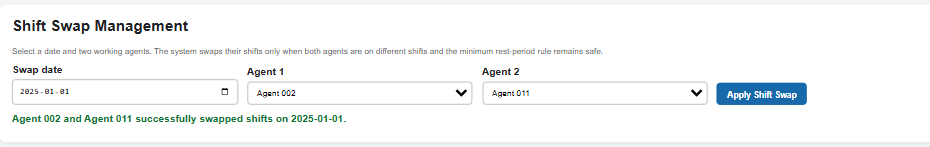

In [20]:
record_prompt('SYS-13')

### SYS-14 — Perform an unsafe shift swap
Expected: Swap is rejected with an explanation

Test: SYS-14 — Unsafe shift swap is rejected
Action: Attempt a swap that breaks the rest rule
Expected: The swap is rejected with an explanation
Saved SYS-14: PASS


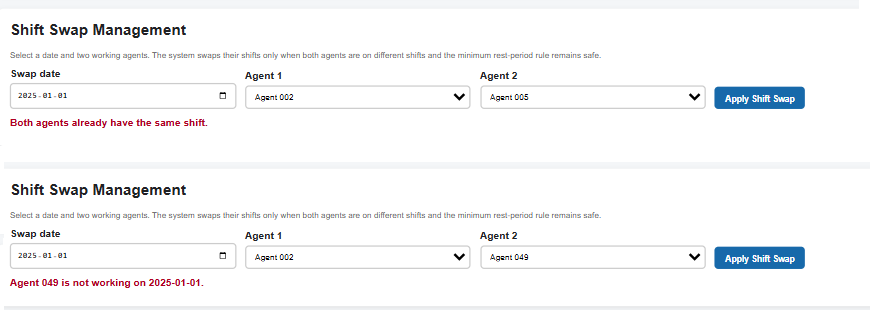

In [21]:
record_prompt('SYS-14')

### SYS-15 — Refresh the browser
Expected: Application remains usable

Test: SYS-15 — Application remains usable after refresh
Action: Refresh the browser and use the dashboard again
Expected: The page loads and remains usable
Saved SYS-15: PASS


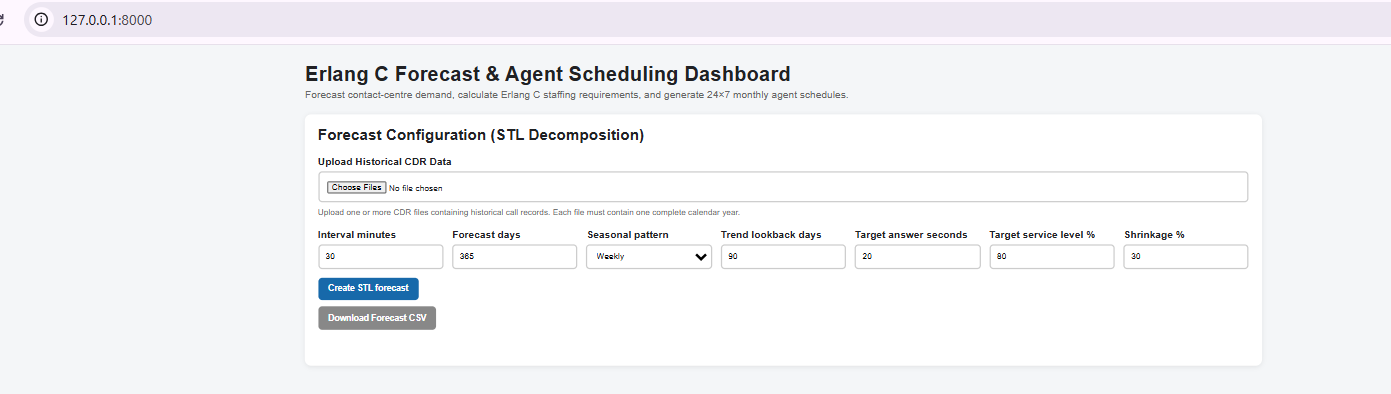

In [14]:
record_prompt('SYS-15')